<a href="https://www.kaggle.com/code/mylastresort/myspotify-dataset-exploratory?scriptVersionId=322574342" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# MySpotify — Dataset Exploration
Million Song Dataset (MSD) — parsing and EDA for all 4 files.

**Files expected** (Kaggle path or local):
- `p02_unique_tracks.txt`
- `p02_msd_tagtraum_cd2.cls`
- `p02_train_triplets.txt` (unzipped)
- `p02_mxm_dataset_train.txt` (unzipped)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict

# ── path config ──────────────────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/mylastresort/p02-myspotify/P02. MySpotify'

TRACKS_FILE   = os.path.join(DATA_DIR, 'p02_unique_tracks.txt')
GENRES_FILE   = os.path.join(DATA_DIR, 'p02_msd_tagtraum_cd2.cls')
TRIPLETS_FILE = os.path.join(DATA_DIR, 'p02_train_triplets.txt/train_triplets.txt')
MXM_FILE      = os.path.join(DATA_DIR, 'p02_mxm_dataset_train.txt/mxm_dataset_train.txt')

print('Data directory:', DATA_DIR)
for f in [TRACKS_FILE, GENRES_FILE, TRIPLETS_FILE, MXM_FILE]:
    size = os.path.getsize(f) / 1e6 if os.path.exists(f) else -1
    status = f'{size:.1f} MB' if size >= 0 else '❌ NOT FOUND'
    print(f'  {os.path.basename(f):45s} {status}')


Data directory: /kaggle/input/datasets/mylastresort/p02-myspotify/P02. MySpotify
  p02_unique_tracks.txt                         84.0 MB
  p02_msd_tagtraum_cd2.cls                      7.5 MB
  train_triplets.txt                            3001.7 MB
  mxm_dataset_train.txt                         102.8 MB


---
## 1. `p02_unique_tracks.txt` — Track metadata
Format: `track_id \t song_id \t artist \t title`

In [2]:
tracks = pd.read_csv(
    TRACKS_FILE,
    sep='<SEP>',
    header=None,
    names=['track_id', 'song_id', 'artist', 'title'],
    encoding='utf-8',
    engine='python',
    on_bad_lines='skip'
)

print(f'Shape : {tracks.shape}')
print(f'Unique tracks  : {tracks["track_id"].nunique():,}')
print(f'Unique artists : {tracks["artist"].nunique():,}')
print(f'Nulls:\n{tracks.isnull().sum()}')
print()
tracks.head(10)


Shape : (1000000, 4)
Unique tracks  : 1,000,000
Unique artists : 72,665
Nulls:
track_id     0
song_id      0
artist       0
title       17
dtype: int64



,track_id,song_id,artist,title
0,TRMMMYQ128F932D901,SOQMMHC12AB0180CB8,Faster Pussy cat,Silent Night
1,TRMMMKD128F425225D,SOVFVAK12A8C1350D9,Karkkiautomaatti,Tanssi vaan
2,TRMMMRX128F93187D9,SOGTUKN12AB017F4F1,Hudson Mohawke,No One Could Ever
3,TRMMMCH128F425532C,SOBNYVR12A8C13558C,Yerba Brava,Si Vos Querés
4,TRMMMWA128F426B589,SOHSBXH12A8C13B0DF,Der Mystic,Tangle Of Aspens
5,TRMMMXN128F42936A5,SOZVAPQ12A8C13B63C,David Montgomery,"Symphony No. 1 G minor ""Sinfonie Serieuse""/All..."
6,TRMMMLR128F1494097,SOQVRHI12A6D4FB2D7,Sasha / Turbulence,We Have Got Love
7,TRMMMBB12903CB7D21,SOEYRFT12AB018936C,Kris Kross,2 Da Beat Ch'yall
8,TRMMMHY12903CB53F1,SOPMIYT12A6D4F851E,Joseph Locke,Goodbye
9,TRMMMML128F4280EE9,SOJCFMH12A8C13B0C2,The Sun Harbor's Chorus-Documentary Recordings,Mama_ mama can't you see ?


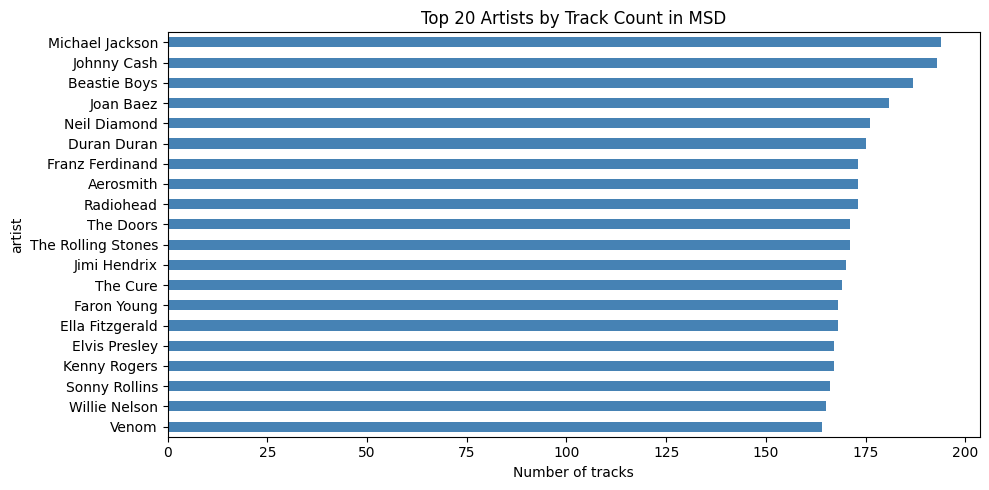

artist
Michael Jackson       194
Johnny Cash           193
Beastie Boys          187
Joan Baez             181
Neil Diamond          176
Duran Duran           175
Franz Ferdinand       173
Aerosmith             173
Radiohead             173
The Doors             171
The Rolling Stones    171
Jimi Hendrix          170
The Cure              169
Faron Young           168
Ella Fitzgerald       168
Elvis Presley         167
Kenny Rogers          167
Sonny Rollins         166
Willie Nelson         165
Venom                 164


In [3]:
# Top 20 artists by track count
top_artists = tracks['artist'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
top_artists.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Number of tracks')
ax.set_title('Top 20 Artists by Track Count in MSD')
plt.tight_layout()
plt.show()

print(top_artists.to_string())

---
## 2. `p02_msd_tagtraum_cd2.cls` — Genre annotations
Format: `track_id \t majority_genre \t minority_genre`  
Lines starting with `#` are comments.

In [4]:
genres = pd.read_csv(
    GENRES_FILE,
    sep='\t',
    header=None,
    names=['track_id', 'majority_genre', 'minority_genre'],
    comment='#',
    encoding='utf-8',
    on_bad_lines='skip'
)

print(f'Shape  : {genres.shape}')
print(f'Tracks with genre label : {genres["track_id"].nunique():,}')
print(f'Unique majority genres  : {genres["majority_genre"].nunique()}')
print(f'Nulls:\n{genres.isnull().sum()}')
print()
genres.head(10)

Shape  : (280831, 3)
Tracks with genre label : 280,831
Unique majority genres  : 15
Nulls:
track_id               0
majority_genre         0
minority_genre    191401
dtype: int64



,track_id,majority_genre,minority_genre
0,TRAAAAK128F9318786,Rock,NaN
1,TRAAAAW128F429D538,Rap,NaN
2,TRAAABD128F429CF47,Rock,RnB
3,TRAAADJ128F4287B47,Rock,NaN
4,TRAAADZ128F9348C2E,Latin,NaN
5,TRAAAED128E0783FAB,Jazz,NaN
6,TRAAAEF128F4273421,Rock,NaN
7,TRAAAEM128F93347B9,Electronic,NaN
8,TRAAAFD128F92F423A,Punk,Rock
9,TRAAAGF12903CEC202,Pop,NaN


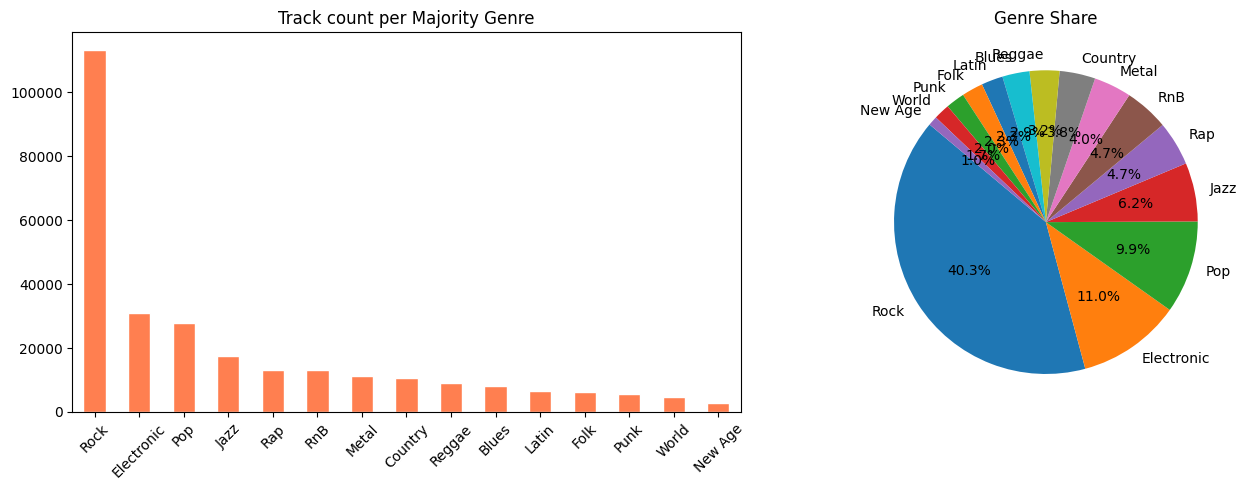

majority_genre
Rock          113150
Electronic     30922
Pop            27756
Jazz           17541
Rap            13272
RnB            13208
Metal          11222
Country        10695
Reggae          8910
Blues           8125
Latin           6444
Folk            6377
Punk            5652
World           4770
New Age         2787


In [5]:
# Genre distribution
genre_counts = genres['majority_genre'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_counts.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Track count per Majority Genre')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Genre Share')

plt.tight_layout()
plt.show()

print(genre_counts.to_string())

In [6]:
# Join tracks + genres — coverage check
tracks_with_genre = tracks.merge(genres, on='track_id', how='left')
coverage = tracks_with_genre['majority_genre'].notna().mean() * 100
print(f'Genre coverage: {coverage:.1f}% of all tracks have a genre label')
tracks_with_genre.head(5)

Genre coverage: 28.1% of all tracks have a genre label


,track_id,song_id,artist,title,majority_genre,minority_genre
0,TRMMMYQ128F932D901,SOQMMHC12AB0180CB8,Faster Pussy cat,Silent Night,NaN,NaN
1,TRMMMKD128F425225D,SOVFVAK12A8C1350D9,Karkkiautomaatti,Tanssi vaan,NaN,NaN
2,TRMMMRX128F93187D9,SOGTUKN12AB017F4F1,Hudson Mohawke,No One Could Ever,Electronic,Rap
3,TRMMMCH128F425532C,SOBNYVR12A8C13558C,Yerba Brava,Si Vos Querés,NaN,NaN
4,TRMMMWA128F426B589,SOHSBXH12A8C13B0DF,Der Mystic,Tangle Of Aspens,NaN,NaN


---
## 3. `p02_train_triplets.txt` — User–Song interactions
Format: `user_id \t song_id \t play_count`  (~48M rows, load a sample first)

In [7]:
# ── Load sample for quick EDA ─────────────────────────────────────────────────
SAMPLE_ROWS = 5_000_000   # set to None for full 48M (slow, ~5 GB RAM)

triplets = pd.read_csv(
    TRIPLETS_FILE,
    sep='\t',
    header=None,
    names=['user_id', 'song_id', 'play_count'],
    nrows=SAMPLE_ROWS,
    dtype={'play_count': np.int32}
)

print(f'Loaded rows    : {len(triplets):,}  ({"sample" if SAMPLE_ROWS else "full dataset"})')
print(f'Unique users   : {triplets["user_id"].nunique():,}')
print(f'Unique songs   : {triplets["song_id"].nunique():,}')
print(f'Total plays    : {triplets["play_count"].sum():,}')
print(f'\nPlay count stats:')
print(triplets['play_count'].describe())
print()
triplets.head(10)

Loaded rows    : 5,000,000  (sample)
Unique users   : 104,474
Unique songs   : 259,745
Total plays    : 14,297,070

Play count stats:
count    5.000000e+06
mean     2.859414e+00
std      6.271404e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      2.213000e+03
Name: play_count, dtype: float64



,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAPDEY12A81C210A9,1
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFNSP12AF72A0E22,1
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFOVM12A58A7D494,1
5,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBNZDC12A6D4FC103,1
6,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBSUJE12A6D4F8CF5,2
7,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBVFZR12A6D4F8AE3,1
8,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBXALG12A8C13C108,1
9,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBXHDL12A81C204C0,1


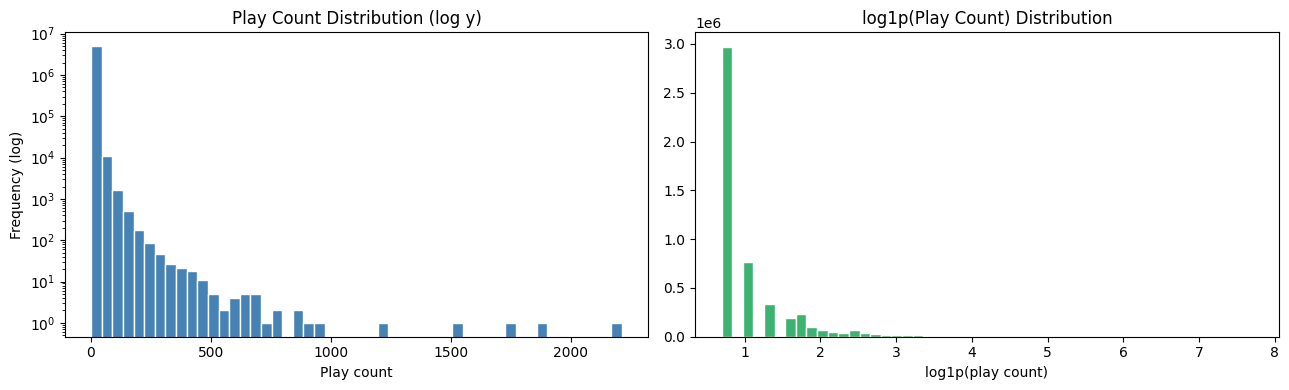

In [8]:
# Play count distribution (log scale — very long tail)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(triplets['play_count'], bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Play Count Distribution (log y)')
axes[0].set_xlabel('Play count')
axes[0].set_ylabel('Frequency (log)')

axes[1].hist(np.log1p(triplets['play_count']), bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('log1p(Play Count) Distribution')
axes[1].set_xlabel('log1p(play count)')

plt.tight_layout()
plt.show()

In [9]:
# Songs per user distribution
songs_per_user = triplets.groupby('user_id')['song_id'].count()
print('Songs per user:')
print(songs_per_user.describe())

# Users per song distribution
users_per_song = triplets.groupby('song_id')['user_id'].count()
print('\nUsers per song:')
print(users_per_song.describe())

Songs per user:
count    104474.000000
mean         47.858797
std          59.424676
min          10.000000
25%          16.000000
50%          27.000000
75%          56.000000
max        1614.000000
Name: song_id, dtype: float64

Users per song:
count    259745.000000
mean         19.249649
std          99.303425
min           1.000000
25%           1.000000
50%           3.000000
75%          11.000000
max       11272.000000
Name: user_id, dtype: float64


In [10]:
# Top 250 songs by total play count — joined with track metadata
song_plays = (
    triplets
    .groupby('song_id')['play_count']
    .sum()
    .reset_index()
    .rename(columns={'play_count': 'total_plays'})
    .sort_values('total_plays', ascending=False)
)

top250 = (
    song_plays
    .head(250)
    .merge(tracks[['song_id', 'artist', 'title']], on='song_id', how='left')
    .reset_index(drop=True)
)
top250.index += 1  # 1-indexed

print('=== TOP 250 TRACKS (non-personalized) ===')
print(top250[['artist', 'title', 'total_plays']].head(20).to_string())

=== TOP 250 TRACKS (non-personalized) ===
                                                                    artist                                                                title  total_plays
1                                                            Dwight Yoakam                                                       You're The One        75001
2                                                                    Björk                                                                 Undo        67422
3                                                            Kings Of Leon                                                              Revelry        56276
4                                                                 Harmonia                                                        Sehr kosmisch        42177
5   Barry Tuckwell/Academy of St Martin-in-the-Fields/Sir Neville Marriner  Horn Concerto No. 4 in E flat K495: II. Romance (Andante cantabile)        41412
6               

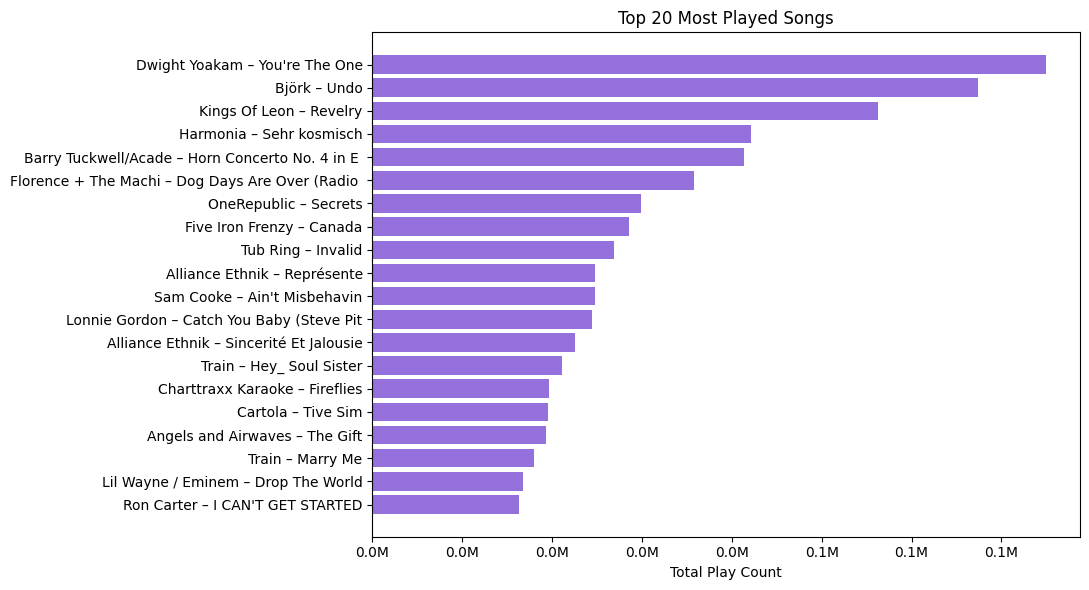

In [11]:
# Top 20 songs — bar chart
top20 = top250.head(20)
labels = [f"{r['artist'][:20]} – {r['title'][:25]}" for _, r in top20.iterrows()]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(labels[::-1], top20['total_plays'].values[::-1], color='mediumpurple')
ax.set_xlabel('Total Play Count')
ax.set_title('Top 20 Most Played Songs')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

---
## 4. `p02_mxm_dataset_train.txt` — Lyrics (bag-of-words, sparse)
Format:
```
%word1,word2,...,word5000     ← vocabulary line
#comments
track_id,mxm_id,widx:cnt,widx:cnt,...
```
Word index starts at **1** (not 0).

In [12]:
def parse_mxm(filepath, max_tracks=None):
    """
    Parse the MusiXmatch sparse bag-of-words file.
    Returns:
        vocab      : list of words (index 0 = word_idx 1)
        bow_records: list of dicts {track_id, mxm_id, word: count, ...}
    """
    vocab = None
    bow_records = []
    n = 0

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # vocabulary line
            if line.startswith('%'):
                vocab = line[1:].split(',')
                print(f'Vocabulary size: {len(vocab):,} words')
                print(f'First 20 words : {vocab[:20]}')
                continue

            # comment lines
            if line.startswith('#'):
                continue

            # data line: track_id,mxm_id,widx:cnt,...
            parts = line.split(',')
            track_id = parts[0]
            mxm_id   = parts[1]
            record   = {'track_id': track_id, 'mxm_id': mxm_id}

            for token in parts[2:]:
                widx, cnt = token.split(':')
                word = vocab[int(widx) - 1]   # 1-indexed → 0-indexed
                record[word] = int(cnt)

            bow_records.append(record)
            n += 1
            if max_tracks and n >= max_tracks:
                break

    return vocab, bow_records


vocab, bow_records = parse_mxm(MXM_FILE, max_tracks=20_000)
print(f'\nParsed {len(bow_records):,} tracks')

Vocabulary size: 5,000 words
First 20 words : ['i', 'the', 'you', 'to', 'and', 'a', 'me', 'it', 'not', 'in', 'my', 'is', 'of', 'your', 'that', 'do', 'on', 'are', 'we', 'am']

Parsed 20,000 tracks


In [13]:
# Build a sparse-friendly DataFrame (only non-zero columns loaded)
mxm_df = pd.DataFrame(bow_records).fillna(0)

# word columns only
word_cols = [c for c in mxm_df.columns if c not in ('track_id', 'mxm_id')]

print(f'mxm_df shape : {mxm_df.shape}  (tracks × meta+words)')
print(f'Word columns : {len(word_cols)}')
print()
mxm_df[['track_id'] + word_cols[:10]].head(5)

mxm_df shape : (20000, 5002)  (tracks × meta+words)
Word columns : 5000



,track_id,i,the,you,to,and,a,me,it,my,is
0,TRAAAAV128F421A322,6.0,4.0,2.0,2.0,5.0,3.0,1.0,1.0,1.0,2.0
1,TRAAABD128F429CF47,10.0,0.0,17.0,8.0,2.0,2.0,1.0,3.0,4.0,3.0
2,TRAAAED128E0783FAB,28.0,15.0,2.0,12.0,22.0,2.0,2.0,4.0,20.0,3.0
3,TRAAAEF128F4273421,5.0,4.0,3.0,2.0,1.0,11.0,0.0,0.0,0.0,9.0
4,TRAAAEW128F42930C0,4.0,0.0,0.0,5.0,7.0,2.0,4.0,0.0,9.0,0.0


Top 30 most frequent words in the lyrics corpus:
i       173149.0
the     156974.0
you     146225.0
to       89679.0
and      89251.0
a        81061.0
it       69248.0
me       65503.0
not      61685.0
in       52571.0
my       51780.0
is       50713.0
of       45435.0
do       39580.0
that     39181.0
your     38754.0
on       35463.0
am       34221.0
we       32988.0
are      32529.0
all      30299.0
will     29764.0
for      28180.0
be       27701.0
no       26498.0
love     25591.0
so       24597.0
have     24476.0
know     22632.0
but      21512.0


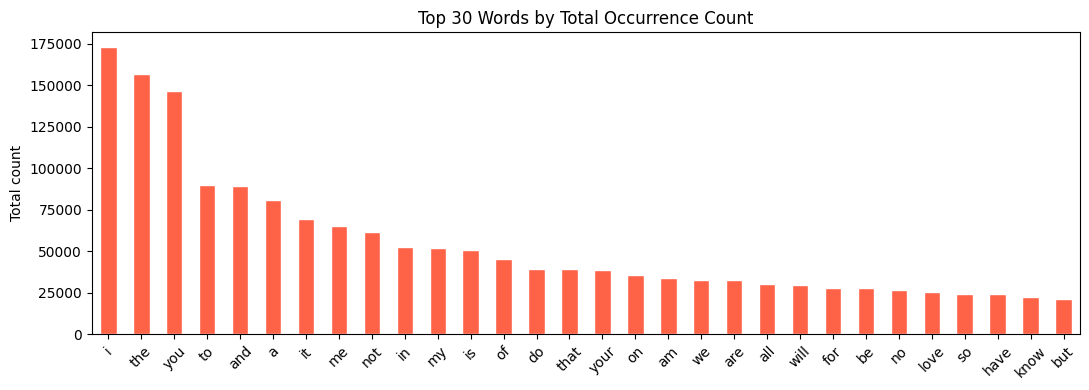

In [14]:
# Most frequent words across all tracks
word_totals = mxm_df[word_cols].sum().sort_values(ascending=False)

print('Top 30 most frequent words in the lyrics corpus:')
print(word_totals.head(30).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
word_totals.head(30).plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Top 30 Words by Total Occurrence Count')
ax.set_ylabel('Total count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Quick keyword search — baseline for Collections feature
def keyword_search(keyword, top_n=50):
    """Find tracks containing a keyword, join with track metadata and play counts."""
    if keyword not in mxm_df.columns:
        print(f'Word "{keyword}" not in top-5000 vocabulary')
        return pd.DataFrame()

    matched = mxm_df[mxm_df[keyword] > 0][['track_id', keyword]].copy()
    matched = matched.merge(tracks[['track_id', 'song_id', 'artist', 'title']], on='track_id', how='left')
    matched = matched.merge(
        song_plays.rename(columns={'total_plays': 'play_count'}),
        on='song_id', how='left'
    )
    matched = matched.sort_values('play_count', ascending=False).head(top_n)
    matched.index = range(1, len(matched) + 1)
    return matched[['artist', 'title', keyword, 'play_count']]


for kw in ['love', 'war', 'money', 'happy', 'alone']:
    result = keyword_search(kw)
    print(f'\n=== Top 5 tracks about "{kw}" ===')
    print(result.head(5).to_string() if not result.empty else '  (not found)')


=== Top 5 tracks about "love" ===
           artist                  title  love  play_count
1   Dwight Yoakam         You're The One   2.0     75001.0
2  Counting Crows              Mr. Jones   4.0      5572.0
3    New Radicals  You Get What You Give   1.0      3627.0
4          Eminem          Hailie's Song   2.0      3102.0
5       Aerosmith                  Crazy   3.0      2994.0

=== Top 5 tracks about "war" ===
          artist                                     title  war  play_count
1  Kings Of Leon                                     Ragoo  1.0      1372.0
2      B.B. King    There Must Be A Better World Somewhere  1.0       864.0
3    Iron Maiden                   These Colours Don't Run  6.0       569.0
4    Lupe Fiasco  Streets On Fire (Explicit Album Version)  2.0       552.0
5      The Trews                             Fire Up Ahead  1.0       537.0

=== Top 5 tracks about "money" ===
          artist                        title  money  play_count
1      The Verve    

---
## 5. Dataset Join Summary

In [16]:
# Full merge: triplets + tracks + genres
full = (
    song_plays
    .merge(tracks[['song_id', 'track_id', 'artist', 'title']], on='song_id', how='left')
    .merge(genres[['track_id', 'majority_genre']], on='track_id', how='left')
)

print('=== Full joined table (sample) ===')
print(full.dropna(subset=['majority_genre']).head(10).to_string())

print(f'\nTotal songs with genre + play data: {full["majority_genre"].notna().sum():,}')

=== Full joined table (sample) ===
               song_id  total_plays            track_id           artist                title majority_genre
0   SOBONKR12A58A7A7E0        75001  TRAEHHJ12903CF492F    Dwight Yoakam       You're The One        Country
1   SOAUWYT12A81C206F1        67422  TRGXQES128F42BA5EB            Björk                 Undo           Rock
2   SOSXLTC12AF72A7F54        56276  TRONYHY128F92C9D11    Kings Of Leon              Revelry           Rock
3   SOFRQTD12A81C233C0        42177  TRDMBIJ128F4290431         Harmonia        Sehr kosmisch           Rock
6   SONYKOW12AB01849C9        29892  TROAQBZ128F9326213      OneRepublic              Secrets           Rock
8   SOUFTBI12AB0183F65        26856  TRIXAZF128F421EE64         Tub Ring              Invalid           Rock
9   SOOFYTN12A6D4F9B35        24828  TRRGQKP128F1469E20  Alliance Ethnik           Représente            Rap
15  SOFLJQZ12A6D4FADA6        19587  TRTNDNE128F1486812          Cartola             Tive Sim

In [17]:
# Top 10 per genre — preview
target_genres = ['Rock', 'Rap', 'Jazz', 'Electronic', 'Pop', 'Blues', 'Country', 'Reggae', 'New Age']

for genre in target_genres:
    subset = full[full['majority_genre'].str.contains(genre, case=False, na=False)]
    top = subset.sort_values('total_plays', ascending=False).head(3)
    if top.empty:
        print(f'\n[{genre}] — no tracks found (check genre label spelling)')
        continue
    print(f'\n=== Top 3 [{genre}] tracks ===')
    for _, r in top.iterrows():
        print(f'  {r["artist"]:30s} | {r["title"][:35]:35s} | {int(r["total_plays"]):>8,} plays')


=== Top 3 [Rock] tracks ===
  Björk                          | Undo                                |   67,422 plays
  Kings Of Leon                  | Revelry                             |   56,276 plays
  Harmonia                       | Sehr kosmisch                       |   42,177 plays

=== Top 3 [Rap] tracks ===
  Alliance Ethnik                | Représente                          |   24,828 plays
  Beastie Boys                   | The Maestro                         |    7,137 plays
  Eminem                         | Without Me                          |    6,517 plays

=== Top 3 [Jazz] tracks ===
  Ron Carter                     | I CAN'T GET STARTED                 |   16,364 plays
  Jacky Terrasson                | Le Jardin d'Hiver                   |    7,763 plays
  Erin Bode                      | Here_ There And Everywhere          |    4,138 plays

=== Top 3 [Electronic] tracks ===
  Southside Spinners             | Luvstruck                           |    8,322 plays

In [18]:
# Sparsity of the user-item matrix
n_users = triplets['user_id'].nunique()
n_songs = triplets['song_id'].nunique()
n_interactions = len(triplets)
sparsity = 1 - n_interactions / (n_users * n_songs)

print('=== User–Item Matrix Stats ===')
print(f'Users        : {n_users:,}')
print(f'Songs        : {n_songs:,}')
print(f'Interactions : {n_interactions:,}')
print(f'Sparsity     : {sparsity:.4%}')   # typically ~99.98%

=== User–Item Matrix Stats ===
Users        : 104,474
Songs        : 259,745
Interactions : 5,000,000
Sparsity     : 99.9816%
